# TOF Plotting 

This notebook intakes the output intensity map csv files from iolite and plots them as heatmaps.

In [1]:
import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family']='Arial'
plt.rcParams['font.size'] = 12


## Functions 

In [2]:
def read_TOF(directory_path, sample_name):
    """
    Reads all CSVs in directory_path that start with sample_name.
    Returns a dictionary: { 'Element': DataFrame }
    """
    data_dict = {}
    
    # 1. Get all files that belong to THIS specific sample
    # Using .startswith ensures we don't accidentally mix up "Grain_3" and "Grain_36"
    all_files = os.listdir(directory_path)
    sample_files = [f for f in all_files if f.startswith(sample_name) and f.endswith('.csv')]
    
    if not sample_files:
        print(f"No files found for sample: {sample_name}")
        return data_dict

    for file_name in sample_files:
        # 2. Extract the element/ratio name
        # We remove the sample name and the extension to get the 'key'
        # Example: "BRc02_grain_36 Pb .csv" -> "Pb"
        clean_key = file_name.replace(sample_name, "").replace(".csv", "").strip()
        
        # 3. Load and clean the data
        file_path = os.path.join(directory_path, file_name)
        df_raw = pd.read_csv(file_path, header=None)
        
        # Convert to numeric and crop the 'data island'
        df_numeric = df_raw.apply(pd.to_numeric, errors='coerce')
        df_cleaned = df_numeric.dropna(how='all', axis=0).dropna(how='all', axis=1)
        
        # Reset coordinates so indices start at 0,0
        df_cleaned = df_cleaned.reset_index(drop=True)
        df_cleaned.columns = range(df_cleaned.shape[1])
        
        data_dict[clean_key] = df_cleaned
        
    return data_dict

In [3]:
def TOF_map_plot(data_dict, sample_name, variable, 
                 figsize=(10, 6), 
                 title_font=None, 
                 cbar_font=None,
                 vmin=None, vmax=None, cmap='viridis',
                 show_plot=True):
    """
    Plots a single concentration map and returns (fig, ax).
    Supports 'rotation' and 'labelpad' inside cbar_font.
    """
    if variable not in data_dict:
        print(f"Error: '{variable}' not found in dictionary.")
        return None, None

    data = data_dict[variable]
    
    # Setup fonts and extract cbar controls
    t_font = title_font.copy()
    c_font = cbar_font.copy()
    pad = c_font.pop('labelpad', 10)
    rot = c_font.pop('rotation', 270)
    
    # Labeling Logic
    display_name = "U/Pb" if variable == "UPb" else variable
    unit = "" if variable == "UPb" else " (ppm)"
    title_str = f"{sample_name} {display_name} Concentration Map"
    cbar_label = f"{display_name}{unit}"

    fig, ax = plt.subplots(figsize=figsize)
    
    # Configure colormap (NaNs as black)
    current_cmap = plt.get_cmap(cmap).copy()
    current_cmap.set_bad(color='black')
    
    im = ax.imshow(data, cmap=current_cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.axis('off')
    
    # Apply Title
    ax.set_title(title_str, fontdict=t_font, pad=15)
    
    # Apply Color Bar with custom rotation and padding
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label, fontdict=c_font, labelpad=pad, rotation=rot)
    
    if 'size' in c_font:
        cbar.ax.tick_params(labelsize=c_font['size'])

    if show_plot:
        plt.show()
    
    return fig, ax

In [4]:
def TOF_mulitplot(data_dict, sample_name, order=None, figsize=None, 
                  title_font=None, cbar_font=None ,
                  cbar_lims=None, cbar_colors=None, type='rows'):
    """
    Plots variables in a 1x4 row ('rows') or 2x2 grid ('cols').
    Returns (fig, axes).
    """
    if order is None:
        order = [k for k in ['U', 'Pb', 'Th', 'UPb'] if k in data_dict]
    
    num_plots = len(order)
    
    # Determine Layout
    if type == 'cols': # 2x2 Grid
        nrows, ncols = 2, 2
        default_figsize = (14, 10)
    else: # 1x4 Row
        nrows, ncols = 1, num_plots
        default_figsize = (5 * num_plots, 5)
        
    actual_figsize = figsize if figsize is not None else default_figsize
    fig, axes = plt.subplots(nrows, ncols, figsize=actual_figsize)
    axes_flat = axes.flatten() if num_plots > 1 else [axes]
    
    # Setup font copies and extract controls
    t_font = title_font.copy()
    c_font_base = cbar_font.copy()
    pad = c_font_base.pop('labelpad', 10)
    rot = c_font_base.pop('rotation', 270)
    
    lims = cbar_lims if cbar_lims else {}
    colors = cbar_colors if cbar_colors else {}

    for i, var in enumerate(order):
        if i >= len(axes_flat): break
        ax = axes_flat[i]
        
        if var not in data_dict:
            ax.axis('off')
            continue
            
        # Get specific limits/colors
        v_min = lims.get(var, {}).get('vmin', None)
        v_max = lims.get(var, {}).get('vmax', None)
        cmap_name = colors.get(var, 'viridis')
        
        cmap_obj = plt.get_cmap(cmap_name).copy()
        cmap_obj.set_bad(color='black')
        
        # Plot
        im = ax.imshow(data_dict[var], cmap=cmap_obj, vmin=v_min, vmax=v_max, aspect='auto')
        ax.axis('off')
        
        # Labels
        display_name = "U/Pb" if var == "UPb" else var
        unit = "" if var == "UPb" else " (ppm)"
        ax.set_title(f"{sample_name} {display_name} Concentration Map", fontdict=t_font, pad=12)
        
        # Colorbar
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(f"{display_name}{unit}", fontdict=c_font_base, labelpad=pad, rotation=rot)
        cbar.ax.tick_params(labelsize=c_font_base.get('size', 12))

    # Clean up empty axes
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    return fig, axes

In [5]:
def TOF_mulitplot(data_dict, sample_name, order=None, figsize=None, 
                  title_font=None, cbar_font=None, 
                  cbar_lims=None, cbar_colors=None, type='rows'):
    """
    Plots variables in a 1x4 row ('rows') or 2x2 grid ('cols').
    Returns (fig, axes).
    """
    if order is None:
        order = [k for k in ['U', 'Pb', 'Th', 'UPb'] if k in data_dict]
    
    num_plots = len(order)
    
    # Determine Layout
    if type == 'cols': # 2x2 Grid
        nrows, ncols = 2, 2
        default_figsize = (14, 10)
    else: # 1x4 Row
        nrows, ncols = 1, num_plots
        default_figsize = (5 * num_plots, 5)
        
    actual_figsize = figsize if figsize is not None else default_figsize
    fig, axes = plt.subplots(nrows, ncols, figsize=actual_figsize)
    axes_flat = axes.flatten() if num_plots > 1 else [axes]
    
    # Setup font copies and extract controls
    t_font = title_font.copy()
    c_font_base = cbar_font.copy()
    pad = c_font_base.pop('labelpad', 10)
    rot = c_font_base.pop('rotation', 270)
    
    lims = cbar_lims if cbar_lims else {}
    colors = cbar_colors if cbar_colors else {}

    for i, var in enumerate(order):
        if i >= len(axes_flat): break
        ax = axes_flat[i]
        
        if var not in data_dict:
            ax.axis('off')
            continue
            
        # Get specific limits/colors
        v_min = lims.get(var, {}).get('vmin', None)
        v_max = lims.get(var, {}).get('vmax', None)
        cmap_name = colors.get(var, 'viridis')
        
        cmap_obj = plt.get_cmap(cmap_name).copy()
        cmap_obj.set_bad(color='black')
        
        # Plot
        im = ax.imshow(data_dict[var], cmap=cmap_obj, vmin=v_min, vmax=v_max, aspect='auto')
        ax.axis('off')
        
        # Labels
        display_name = "U/Pb" if var == "UPb" else var
        unit = "" if var == "UPb" else " (ppm)"
        ax.set_title(f" {display_name}", fontdict=t_font, pad=12)
        
        # Colorbar
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(f"{display_name}{unit}", fontdict=c_font_base, labelpad=pad, rotation=rot)
        cbar.ax.tick_params(labelsize=c_font_base.get('size', 12))

    # Clean up empty axes
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    return fig, axes

## Data Wrangling

In [6]:
brc_36_fp='../data/geochron/TOF/BRc02_grain_36'

brc_36=read_TOF(brc_36_fp,'BRc02_grain_36')

In [7]:
brc_47_fp='../data/geochron/TOF/BRc02_grain_47'
brc_47=read_TOF(brc_47_fp,sample_name='BRc02_grain_47')

In [8]:
brc_15_fp='../data/geochron/TOF/BRc_grain_15'
brc_15=read_TOF(brc_15_fp,sample_name='BRc_grain_15')

In [9]:
brc_62_fp='../data/geochron/TOF/BRc02_grain_62'
brc_62=read_TOF(brc_62_fp,sample_name='BRc02_grain_62')

In [10]:
bre_22_fp='../data/geochron/TOF/BRe_grain_22'
bre_22=read_TOF(bre_22_fp,sample_name='BRe_grain_22')

In [11]:
lra_12_fp='../data/geochron/TOF/LRa01_grain_12'
lra_12=read_TOF(lra_12_fp,sample_name='LRa01_grain_12')

In [12]:
lra_52_fp='../data/geochron/TOF/LRa01_grain_52'
lra_52=read_TOF(lra_52_fp,sample_name='LRa01_grain_52')

## Plotting

### Font Dictionaries

In [13]:

title_font = {
    'family': 'Arial',
    'weight': 'semibold',
    'size': 24
}

cbar_font = {
    'family': 'Arial',
    'weight': 'normal',
    'size': 14,
    'rotation': 270, 
    'labelpad': 15
}

### BRc02 Grain 36

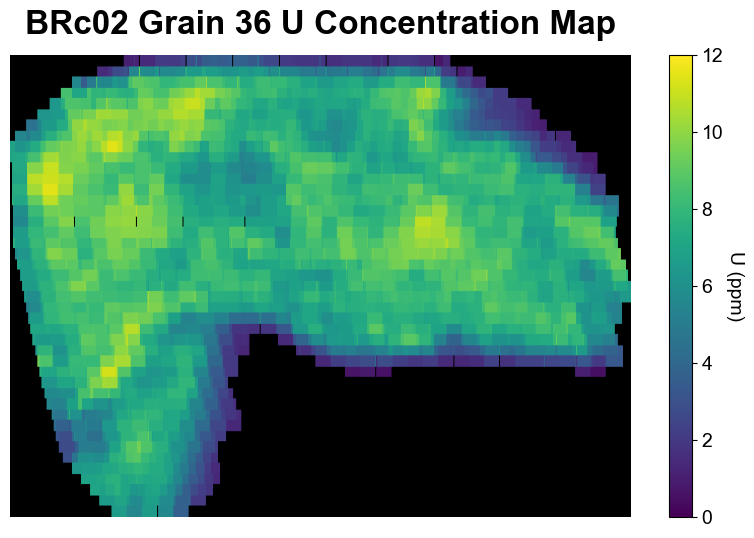

In [14]:
fig,ax=TOF_map_plot(brc_36,'BRc02 Grain 36',variable='U',title_font=title_font,cbar_font=cbar_font,vmin=0,vmax=12)

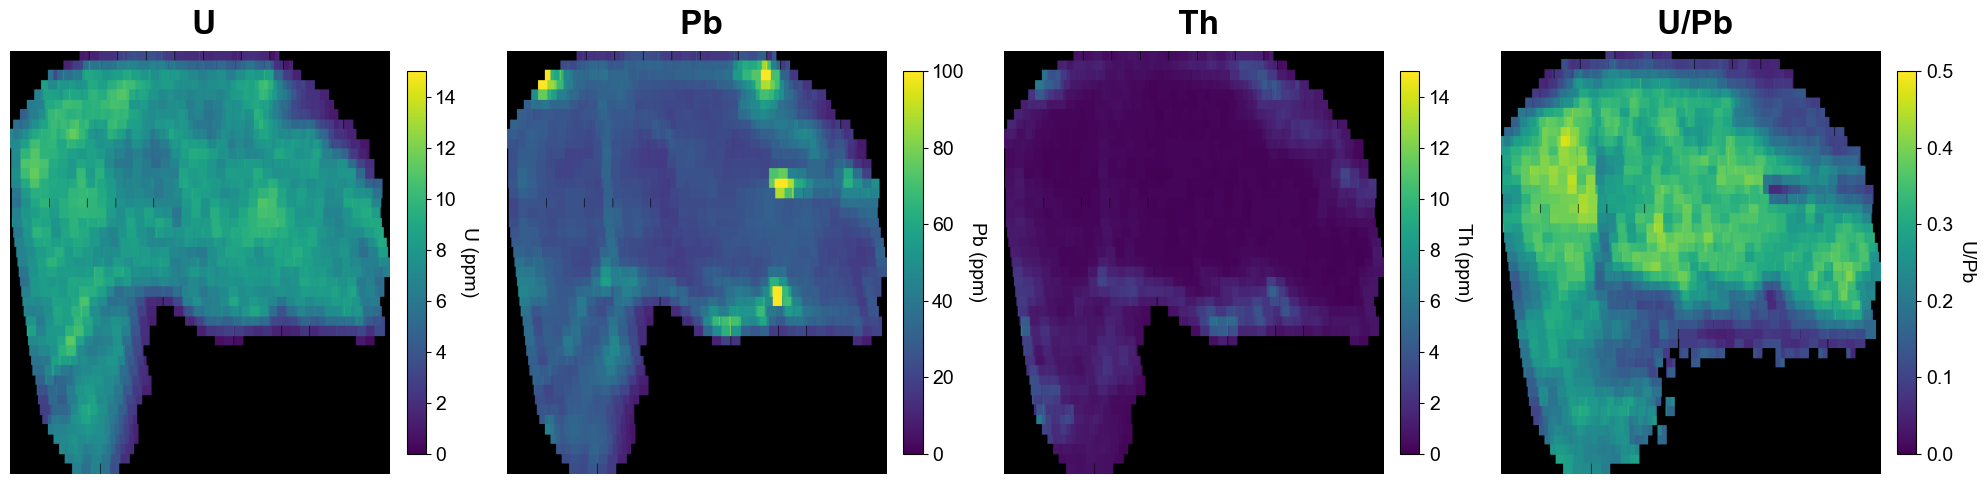

In [15]:
custom_lims = {
    'U': {'vmin': 0, 'vmax': 15},
    'Pb': {'vmin': 0, 'vmax': 100},
    'Th':{'vmin':0,'vmax':15},
    'UPb':{'vmin':0,'vmax':0.5}
}

fig, axes = TOF_mulitplot(
    data_dict=brc_36, 
    sample_name="BRc02 Grain 36", 
    type='rows', 
    title_font=title_font,
    cbar_font=cbar_font,
    cbar_lims=custom_lims
)

fig.tight_layout()

### BRc02 Grain 47

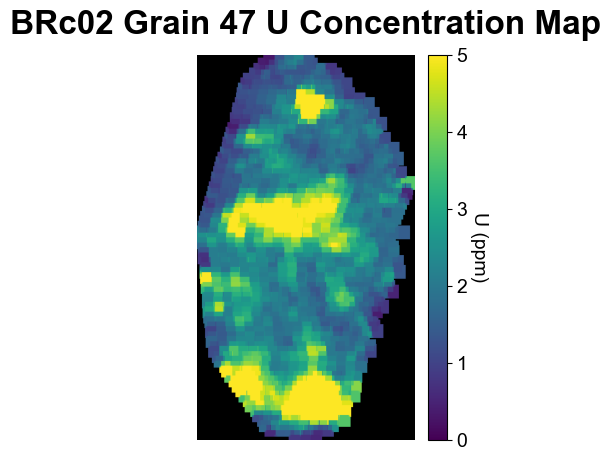

In [16]:
fig,ax=TOF_map_plot(brc_47,'BRc02 Grain 47',variable='U',title_font=title_font,cbar_font=cbar_font,vmin=0,vmax=5,figsize=(3.5,5))

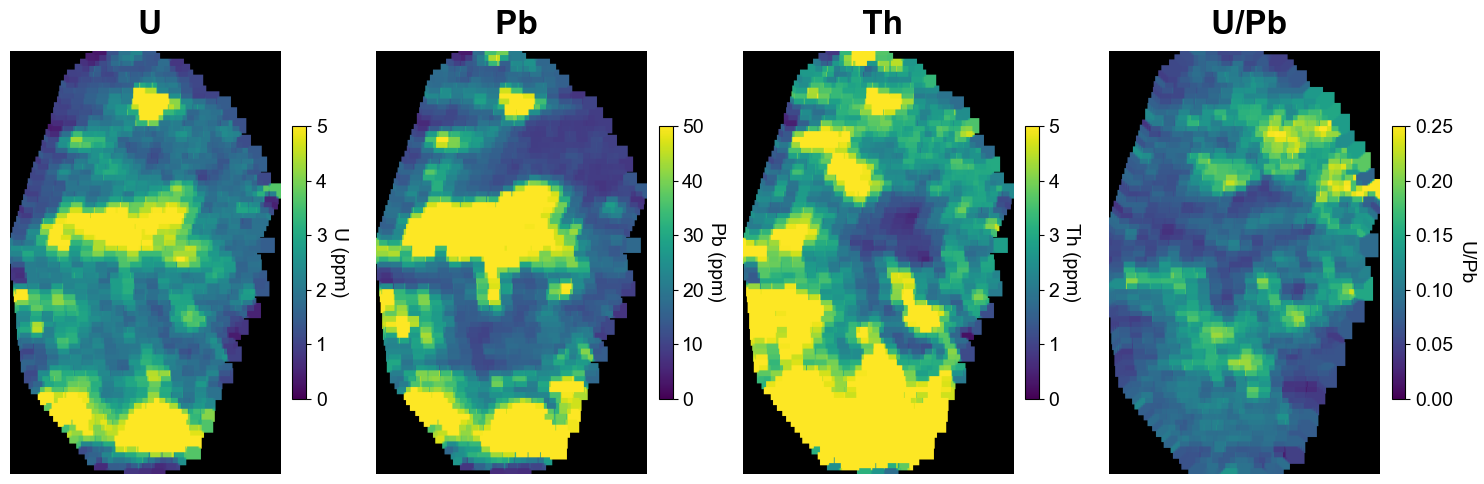

In [18]:
custom_lims = {
    'U': {'vmin': 0, 'vmax': 5},
    'Pb': {'vmin': 0, 'vmax': 50},
    'Th':{'vmin':0,'vmax':5},
    'UPb':{'vmin':0,'vmax':0.25}
}

fig, axes = TOF_mulitplot(
    data_dict=brc_47, 
    sample_name="BRc02 Grain 47", 
    type='rows', 
    title_font=title_font,
    cbar_font=cbar_font,
    cbar_lims=custom_lims,
    figsize=(15,5)
)

fig.tight_layout()
fig.savefig('../figures/ToF/BRc02_grain_47/BRc02_grain_47.pdf',bbox_inches='tight',dpi=300)

### BRc Grain 15

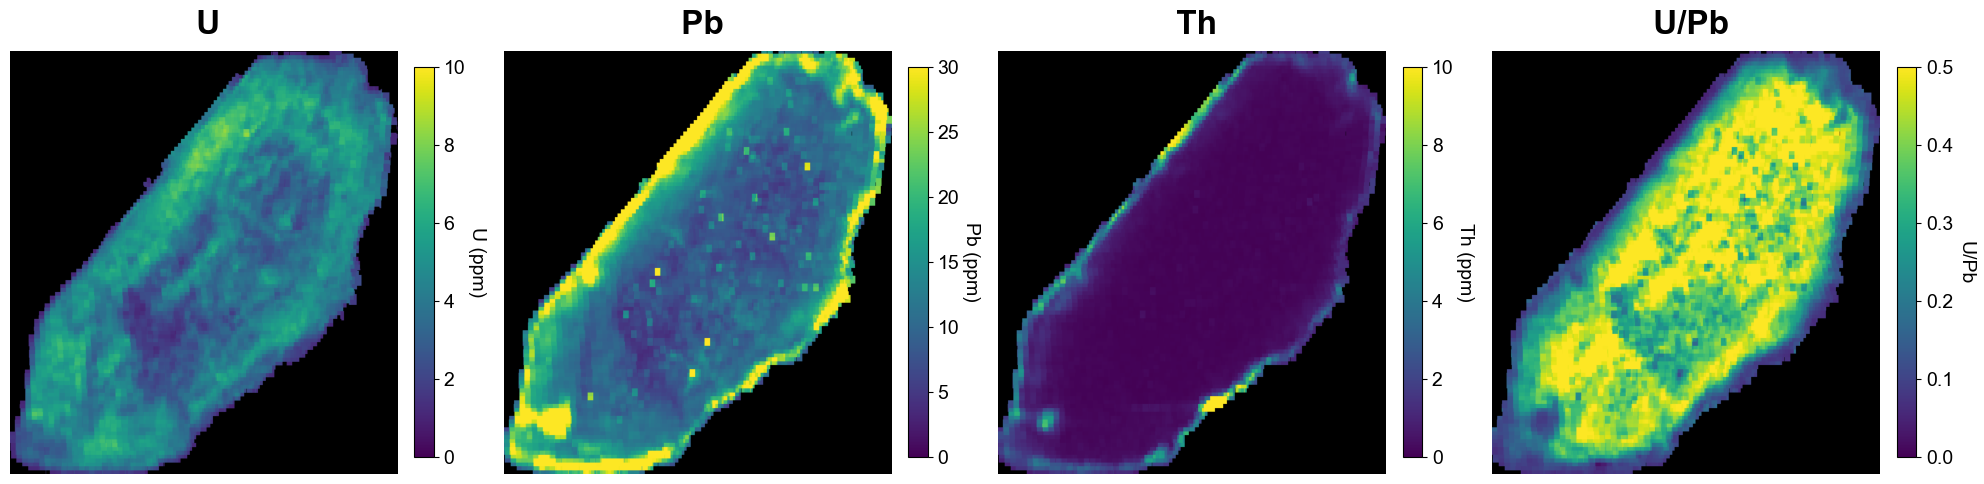

In [19]:
custom_lims = {
    'U': {'vmin': 0, 'vmax': 10},
    'Pb': {'vmin': 0, 'vmax': 30},
    'Th':{'vmin':0,'vmax':10},
    'UPb':{'vmin':0,'vmax':0.5}
}

fig, axes = TOF_mulitplot(
    data_dict=brc_15, 
    sample_name="BRc Grain 15", 
    type='rows', 
    title_font=title_font,
    cbar_font=cbar_font,
    cbar_lims=custom_lims
)

fig.tight_layout()

fig.savefig('../figures/ToF/BRc_grain_15/BRc_grain_15.pdf',bbox_inches='tight',dpi=300)

### BRc02 Grain 62

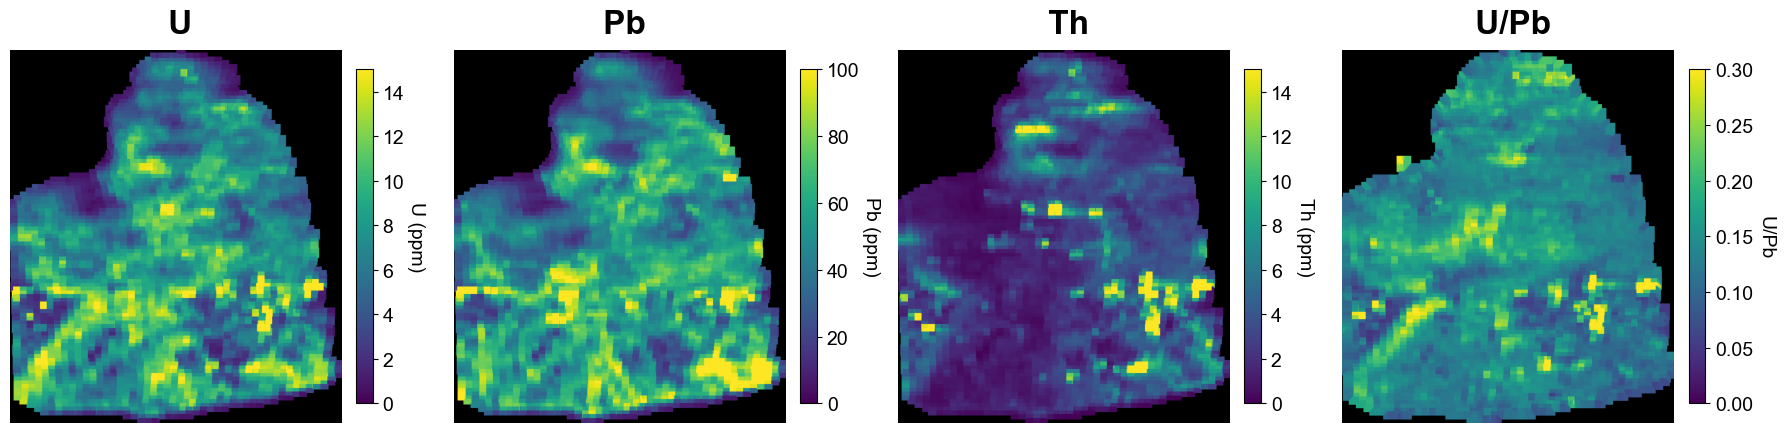

In [20]:
custom_lims = {
    'U': {'vmin': 0, 'vmax': 15},
    'Pb': {'vmin': 0, 'vmax': 100},
    'Th':{'vmin':0,'vmax':15},
    'UPb':{'vmin':0,'vmax':0.3}
}

fig, axes = TOF_mulitplot(
    data_dict=brc_62, 
    sample_name="BRc02 Grain 62", 
    type='rows', 
    title_font=title_font,
    cbar_font=cbar_font,
    cbar_lims=custom_lims,
     figsize=(18,4.5)
)

fig.tight_layout()
fig.savefig('../figures/TOF/BRc02_grain_62/BRc02_grain_62.pdf',bbox_inches='tight',dpi=300)

### BRe Grain 22

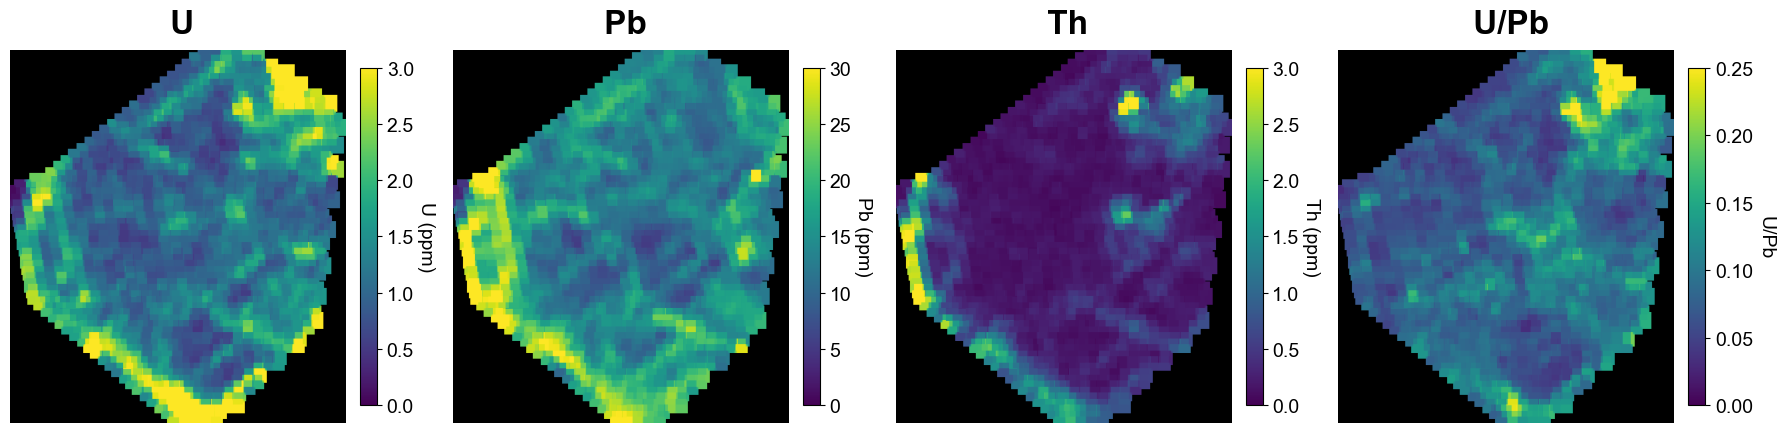

In [21]:
custom_lims = {
    'U': {'vmin': 0, 'vmax': 3},
    'Pb': {'vmin': 0, 'vmax': 30},
    'Th':{'vmin':0,'vmax':3},
    'UPb':{'vmin':0,'vmax':0.25}
}

fig, axes = TOF_mulitplot(
    data_dict=bre_22, 
    sample_name="BRe Grain 22", 
    type='rows', 
    title_font=title_font,
    cbar_font=cbar_font,
    cbar_lims=custom_lims,
     figsize=(18,4.5)
)

fig.tight_layout()

fig.savefig('../figures/TOF/BRe_grain_22/BRe_grain_22.pdf',bbox_inches='tight',dpi=300)

### LRa01 Grain 12

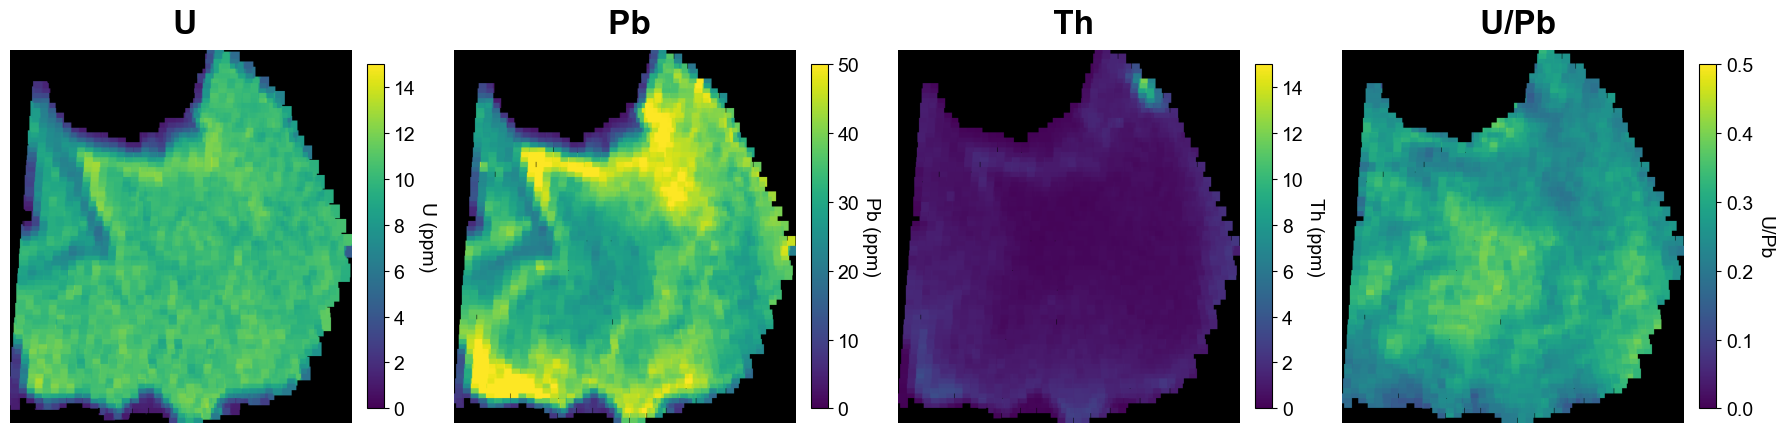

In [22]:
custom_lims = {
    'U': {'vmin': 0, 'vmax': 15},
    'Pb': {'vmin': 0, 'vmax': 50},
    'Th':{'vmin':0,'vmax':15},
    'UPb':{'vmin':0,'vmax':0.5}
}

fig, axes = TOF_mulitplot(
    data_dict=lra_12, 
    sample_name="LRa01 Grain 12", 
    type='rows', 
    title_font=title_font,
    cbar_font=cbar_font,
    cbar_lims=custom_lims,
    figsize=(18,4.5)
)

fig.tight_layout()

fig.savefig('../figures/TOF/LRa01_grain_12/LRa01_grain_12.pdf',bbox_inches='tight',dpi=300)

### LRa01 Grain 52

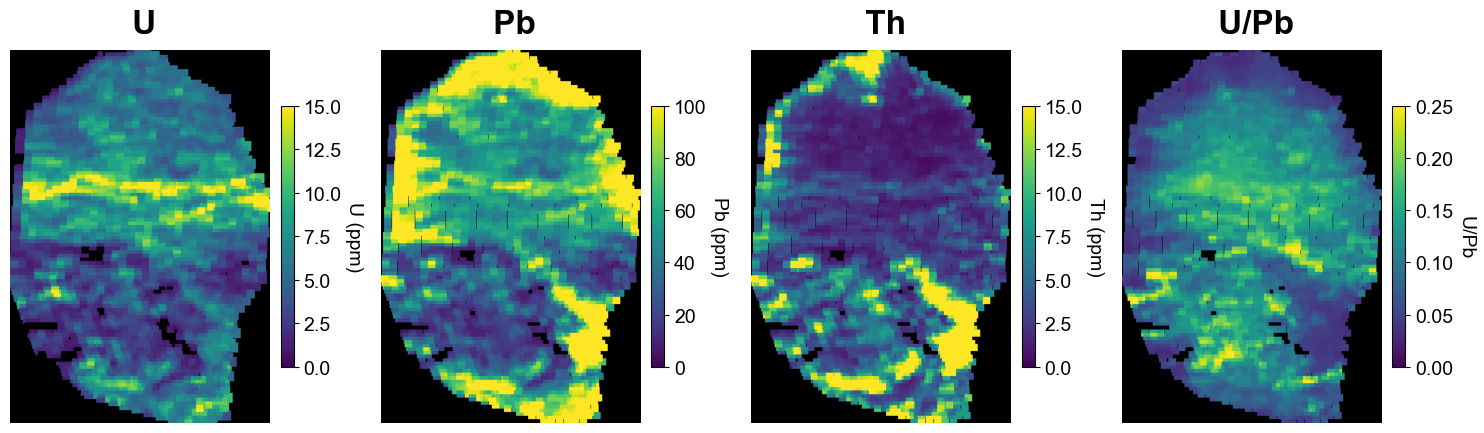

In [23]:
custom_lims = {
    'U': {'vmin': 0, 'vmax': 15},
    'Pb': {'vmin': 0, 'vmax': 100},
    'Th':{'vmin':0,'vmax':15},
    'UPb':{'vmin':0,'vmax':0.25}
}

fig, axes = TOF_mulitplot(
    data_dict=lra_52, 
    sample_name="LRa01 Grain 12", 
    type='rows', 
    title_font=title_font,
    cbar_font=cbar_font,
    cbar_lims=custom_lims,
    figsize=(15,4.5)
)

fig.tight_layout()
fig.savefig('../figures/TOF/LRa01_grain_52/LRa01_grain_52.pdf',bbox_inches='tight',dpi=300)